In [ ]:
# -*- coding: utf-8 -*-

import numpy as np
from scipy.io import netcdf
from scipy.optimize import minimize
import scipy.interpolate as interp
import matplotlib.pyplot as plt

file = '/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps/'

solps = netcdf.netcdf_file(file + "balance.nc") #load solps
nx = solps.dimensions['nx_plus2']
ny = solps.dimensions['ny_plus2']

#load heat fluxes
te = solps.variables['te'].data
fhe_32 = solps.variables['fhe_32'].data
fne = solps.variables['fne'].data
fhex_32 = fhe_32[0,:,:]*5/3+fne[0,:,:]*te
fhey_32 = fhe_32[1,:,:]
fhe_52 = solps.variables['fhe_52'].data
fhex_52 = fhe_52[0,:,:]
fhey_52 = fhe_52[1,:,:]
fhe_thermj = solps.variables['fhe_thermj'].data
fhex_thermj = fhe_thermj[0,:,:]
fhey_thermj = fhe_thermj[1,:,:]
fhe_cond = solps.variables['fhe_cond'].data
fhex_cond = fhe_cond[0,:,:]
fhey_cond = fhe_cond[1,:,:]
fhe_dia = solps.variables['fhe_dia'].data
fhex_dia = fhe_dia[0,:,:]
fhey_dia = fhe_dia[1,:,:]
fhe_ecrb = solps.variables['fhe_ecrb'].data
fhex_ecrb = fhe_ecrb[0,:,:]
fhey_ecrb = fhe_ecrb[1,:,:]
fhe_strange = solps.variables['fhe_strange'].data
fhex_strange = fhe_strange[0,:,:]
fhey_strange = fhe_strange[1,:,:]
fhe_pschused = solps.variables['fhe_pschused'].data
fhex_pschused = fhe_pschused[0,:,:]
fhey_pschused = fhe_pschused[1,:,:]
fhex_tot = fhex_32 + fhex_52 + fhex_thermj + fhex_cond + fhex_dia + fhex_ecrb + fhex_strange + fhex_pschused
fhey_tot = fhey_32 + fhey_52 + fhey_thermj + fhey_cond + fhey_dia + fhey_ecrb + fhey_strange + fhey_pschused

# Fluxes (ions)
ti = solps.variables['ti'].data
fna = solps.variables['fna_pinch'].data + \
        solps.variables['fna_pll'].data + \
        solps.variables['fna_drift'].data + \
        solps.variables['fna_ch'].data + \
        solps.variables['fna_nanom'].data + \
        solps.variables['fna_panom'].data + \
        solps.variables['fna_pschused'].data

fhi_32 = solps.variables['fhi_32'].data
fhix_32 = fhi_32[0,:,:]
fhix_KE = np.zeros((ny,nx))

kinrgy = solps.variables['kinrgy'].data
for i in range(np.shape(fna)[0]):
    fhix_32 = fhix_32+fna[i,0,:,:]*ti
    fhix_KE = fhix_KE+fna[i, 0, :, :]*kinrgy[i, :, :]

fhix_32 = fhi_32[0,:,:]    
fhiy_32 = fhi_32[1,:,:]
fhi_52 = solps.variables['fhi_52'].data
fhix_52 = fhi_52[0,:,:]
fhiy_52 = fhi_52[1,:,:]
fhi_cond = solps.variables['fhi_cond'].data
fhix_cond = fhi_cond[0,:,:]
fhiy_cond = fhi_cond[1,:,:]
fhi_dia = solps.variables['fhi_dia'].data
fhix_dia = fhi_dia[0,:,:]
fhiy_dia=  fhi_dia[1,:,:]
fhi_ecrb = solps.variables['fhi_ecrb'].data
fhix_ecrb = fhi_ecrb[0,:,:]
fhiy_ecrb = fhi_ecrb[1,:,:]
fhi_strange = solps.variables['fhi_strange'].data
fhix_strange = fhi_strange[0,:,:]
fhiy_strange = fhi_strange[1,:,:]
fhi_pschused = solps.variables['fhi_pschused'].data
fhix_pschused = fhi_pschused[0,:,:]
fhiy_pschused = fhi_pschused[1,:,:]
fhi_inert = solps.variables['fhi_inert'].data
fhix_inert = fhi_inert[0,:,:]
fhiy_inert = fhi_inert[1,:,:]
fhi_vispar = solps.variables['fhi_vispar'].data
fhix_vispar = fhi_vispar[0,:,:]
fhiy_vispar = fhi_vispar[1,:,:]
fhi_anml = solps.variables['fhi_anml'].data
fhix_anml = fhi_anml[0,:,:]
fhiy_anml = fhi_anml[1,:,:]
fhi_kevis = solps.variables['fhi_kevis'].data
fhix_kevis = fhi_kevis[0,:,:]
fhiy_kevis = fhi_kevis[1,:,:]

fhix_tot = fhix_32 + fhix_52 + fhix_cond + fhix_dia + fhix_ecrb + fhix_strange + \
            fhix_pschused + fhix_inert + fhix_vispar + fhix_anml + fhix_kevis  + fhix_KE
            
fhix_j = fhix_dia + fhix_inert + fhix_vispar + fhix_anml + fhix_pschused
fhex_j = fhex_dia + fhex_pschused

fhiy_tot = fhiy_32 + fhiy_52 + fhiy_cond + fhiy_dia + fhiy_ecrb + fhiy_strange + \
            fhiy_pschused + fhiy_inert + fhiy_vispar + fhiy_anml + fhiy_kevis

Qtot = fhix_tot + fhex_tot

#Plus one conversion only works for leftix, with leftiy causes issues.
leftix = solps.variables['leftix'].data+1
leftiy = solps.variables['leftiy'].data
hy = solps.variables['hy'].data
hx = solps.variables['hx'].data
bb = solps.variables['bb'].data
B = bb[3, :, :]  # total magnetic field strength
dv = solps.variables['vol'].data

#evaluate parallel area
apll = (dv/hx)*np.abs(bb[0,:,:]/B)
apllx = np.zeros((ny,nx))
xcut = np.argwhere(np.diff(leftix[0,:])<1)+1
if len(xcut) == 0: #slab
    leftix = leftix-1
    #Maps to left cell face. In slabs this will be the same as apll as the cells are consistent rectangles unlike in tokamaks
    for iy in range(ny):
        for ix in range(nx):
            apllx[iy,ix] = (apll[leftiy[iy,ix],leftix[iy,ix]]*dv[iy,ix]+ \
                                  apll[iy,ix]*dv[leftiy[iy,ix],leftix[iy,ix]])\
                                 /(dv[iy,ix]+dv[leftiy[iy,ix],leftix[iy,ix]])
else:
    for iy in range(ny):
        for ix in range(nx):
            if leftix[iy,ix]<0:
                continue
            apllx[iy,ix] = (apll[leftiy[iy,ix],leftix[iy,ix]]*dv[iy,ix]+ \
                                  apll[iy,ix]*dv[leftiy[iy,ix],leftix[iy,ix]])\
                                 /(dv[iy,ix]+dv[leftiy[iy,ix],leftix[iy,ix]])
            
r = solps.variables['crx'].data
z = solps.variables['cry'].data
cr = np.mean(solps.variables['crx'].data,0)
cz = np.mean(solps.variables['cry'].data,0)
cr_x = np.zeros((ny, nx-1))
cz_x = np.zeros((ny, nx-1))
cr_y = np.zeros((ny-1, nx))
cz_y = np.zeros((ny-1, nx))

for iy in range(ny):
   for ix in range(nx-1):
       cr_x[iy,ix]= (r[0,iy,ix+1]+r[2,iy,ix+1])/2
       cz_x[iy,ix]= (z[0,iy,ix+1]+z[2,iy,ix+1])/2

for iy in range(ny-1):
    for ix in range(nx):
        cr_y[iy,ix]=(r[0,iy+1,ix]+r[1,iy+1,ix])/2
        cz_y[iy,ix]=(z[0,iy+1,ix]+z[1,iy+1,ix])/2

sep_ind = int(solps.variables['jsep'].data)+2 #separatrix index
OMP_ind = int(solps.variables['jxa'].data) #outer midplane index
targ_ind = len(cr[0])-1 #lo targ coords        
Spec = [0, 1] #species to plot D0=0, D+1 = 1

cr_OMP = cr[:,OMP_ind]
cz_OMP = cz[:,OMP_ind]
cr_targ = cr[:,targ_ind]
cz_targ = cz[:,targ_ind]

# y-y_sep at outer mid-plane (cm):
hyc = np.sqrt(np.diff(cr, axis=0)**2 + np.diff(cz, axis=0)**2)
yOMP = np.cumsum(hyc[:,OMP_ind])
yOMP = np.insert(yOMP,0,0.0)

cr_y_sep1=cr_y[sep_ind+1,OMP_ind] 
cr_y_sep2=cr_y[sep_ind+2,OMP_ind]
cr_ydiff = np.diff([cr_y_sep1,cr_y_sep2], axis=0)

cz_y_sep1=cz_y[sep_ind+1,OMP_ind] 
cz_y_sep2=cz_y[sep_ind+2,OMP_ind]
cz_ydiff = np.diff([cz_y_sep1,cz_y_sep2], axis=0)

dys1 = np.sqrt(cr_ydiff**2 + cz_ydiff**2)   
yOMP = yOMP-yOMP[sep_ind+2]+dys1/2
ymysepomp = yOMP*100 #conversion to cm

if len(xcut) == 0: #used if slab is present.
    #finds y and x coord where maximum Qtot exists
    Qmax = (np.max(Qtot[:,:]))
    imax = np.argwhere(Qtot==Qmax)
    iymax = imax[0][0]
    ixmax = imax[0][1]
else:
    ixmax = (xcut[4]+2-np.argwhere(np.diff(np.sum(Qtot[sep_ind+1:,xcut[4]+1],axis=1))<0))[0][0]

#Remove guard cells prior to calculation
sh = np.shape(solps.variables['ne'].data)
Ir = np.arange(1,sh[0]-1,1).astype(int) #used to remove guard cells
Iz = np.arange(1,sh[1]-1,1).astype(int)
Qtot = Qtot[Ir,:]
Qtot = Qtot[:,Iz]
apllx = apllx[Ir,:]
apllx = apllx[:,Iz]
WWpar=(Qtot[:,ixmax]/(apllx[:,ixmax]))
ymysepomp = ymysepomp[1:-1]

WWpar_max = np.max(WWpar) #find power flux max at xpoint and its ny position
iymax = np.argwhere(WWpar==WWpar_max)[0][0]
ysep = (ymysepomp[iymax:] - ymysepomp[iymax])

xwhm_par_interp = interp.interp1d(WWpar[iymax:], ysep,  axis=0 ,kind="nearest", fill_value="extrapolate")
xwhm_par_ol = (xwhm_par_interp((WWpar_max/2)))/np.log(2)
print('lambda_q (hfhm) = ', xwhm_par_ol*10, 'mm') #print lq (convert from cm to mm)

#attempting exponential fit
xtmp = ymysepomp*10
xMP = xtmp[xtmp>0]
WWpar_xpt = WWpar[xtmp>0]
INDSFIT=np.arange(1,7,7)
mask = np.zeros_like(xMP, dtype=bool)
mask[np.array(INDSFIT)] = True

def fitfunc(p, s):
    A, lam = p
    return A * np.exp(-s / lam) # Exponential fit: q(s) = A * exp(-s / lambda_q)

xfit = xMP[mask]
yfit = WWpar_xpt[mask]

def minfunc(p):
    return np.linalg.norm(fitfunc(p, xfit) - yfit)

p0 = np.array([2e6, 7])  # Initial guess: A (W/m^2), lambda_q (m)
result = minimize(minfunc, p0, method='Nelder-Mead')
pfit = result.x  # [A, lambda_q]
print('lambda_q (exponential fit) = ', pfit[1], 'mm') #lq in mm

lambda_q (hfhm) =  1.2472582830649346 mm
lambda_q (exponential fit) =  12.717516481562363 mm


/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_9443/2667901560.py:11: DeprecationWarning: Please import `netcdf_file` from the `scipy.io` namespace; the `scipy.io.netcdf` namespace is deprecated and will be removed in SciPy 2.0.0.
  solps = netcdf.netcdf_file(file + "balance.nc") #load solps
/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_9443/2667901560.py:11: RuntimeWarning: Cannot close a netcdf_file opened with mmap=True, when netcdf_variables or arrays referring to its data still exist. All data arrays obtained from such files refer directly to data on disk, and must be copied before the file can be cleanly closed. (See netcdf_file docstring for more information on mmap.)
  solps = netcdf.netcdf_file(file + "balance.nc") #load solps
/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_9443/2667901560.py:157: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element 

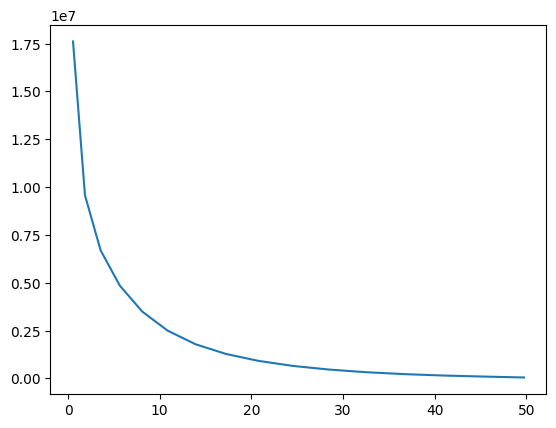

In [ ]:
fig, ax = plt.subplots()
ax.plot(xMP, WWpar_xpt)
ax.plot(xMP[mask], fitfunc(pfit, xMP[mask]), '--')
plt.show()